# Portfolio Risk Simulation and Analysis

This mini-project analyses the market risk using market returns of two portfolios, one with diversified assets, the other with all assets concentrated in the technology sector.

The objective is to:
- estimate portfolio volatility using covariance and correlation analysis
- investigate the effect of diversification on portfolio risk
- analyse systematic market risk using beta and CAPM
- simulate potential future portfolio values over a one-year horizon using Monte Carlo methods
- quantify downside risk using Value at Risk (VaR) and Conditional Value at Risk (CVaR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## Data and Return Calculation

Daily closing prices are obtained for some tech assets: (Apple (AAPL), Microsoft (MSFT), Google (GOOG), Nvidia (NVDA), AMD, Intel (INTC), Amazon (AMZN), Tesla (TSLA), Adobe (ADBE), and Cisco Systems (CSCO)), 
and other assets: (JPMorgan Chase & Co. (JPM), Exxon Mobil (XOM), Walmart (WMT), Johnson & Johnson (JNJ), Gold (GLD), and S&P 500 (SPY)), 
for the years 2015-2023.

Simple daily returns are computed as percentage changes in closing prices.
These returns form the basis for portfolio construction and risk estimation.

In [2]:
tickers = ['AAPL', 'MSFT', 'GOOG', 'NVDA', 'JPM', 'XOM', 'WMT', 'JNJ', 'GLD', 'SPY', 'AMD', 'INTC', 'AMZN', 'TSLA', 'ADBE', 'CSCO']
start_date = '2015-01-01'
end_date = '2023-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']
data.head()

[*********************100%***********************]  16 of 16 completed


Ticker,AAPL,ADBE,AMD,AMZN,CSCO,GLD,GOOG,INTC,JNJ,JPM,MSFT,NVDA,SPY,TSLA,WMT,XOM
Date,,,,,,,,,,,,,,,,
2015-01-02,24.192604,72.339996,2.67,15.4260,19.603914,114.080002,25.939945,27.896463,76.110931,46.274307,39.681732,0.482423,170.125015,14.620667,23.127542,57.145557
2015-01-05,23.511059,71.980003,2.66,15.1095,19.213400,115.800003,25.399216,27.581898,75.579323,44.837719,39.316833,0.474275,167.052582,14.006000,23.060232,55.581955
2015-01-06,23.513266,70.529999,2.63,14.7645,19.206299,117.120003,24.810535,27.067844,75.207939,43.675129,38.739773,0.459896,165.479141,14.085333,23.237930,55.286453
2015-01-07,23.842976,71.110001,2.58,14.9210,19.383802,116.430000,24.768026,27.635593,76.868225,43.741776,39.231964,0.458697,167.541168,14.063333,23.854485,55.846634
2015-01-08,24.759077,72.919998,2.61,15.0230,19.532917,115.940002,24.846123,28.149649,77.472618,44.719250,40.386108,0.475952,170.514206,14.041333,24.357964,56.776188


In [3]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,ADBE,AMD,AMZN,CSCO,GLD,GOOG,INTC,JNJ,JPM,MSFT,NVDA,SPY,TSLA,WMT,XOM
Date,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.004976,-0.003745,-0.020517,-0.019920,0.015077,-0.020845,-0.011276,-0.006985,-0.031045,-0.009196,-0.016890,-0.018060,-0.042041,-0.002910,-0.027362
2015-01-06,0.000094,-0.020145,-0.011278,-0.022833,-0.000370,0.011399,-0.023177,-0.018637,-0.004914,-0.025929,-0.014677,-0.030318,-0.009419,0.005664,0.007706,-0.005317
2015-01-07,0.014022,0.008223,-0.019011,0.010600,0.009242,-0.005891,-0.001713,0.020975,0.022076,0.001526,0.012705,-0.002606,0.012461,-0.001562,0.026532,0.010132
2015-01-08,0.038422,0.025453,0.011628,0.006836,0.007693,-0.004209,0.003153,0.018601,0.007863,0.022346,0.029418,0.037618,0.017745,-0.001564,0.021106,0.016645
2015-01-09,0.001073,-0.014811,0.007663,-0.011749,0.010178,0.011385,-0.012951,0.001908,-0.013629,-0.017387,-0.008405,0.004028,-0.008013,-0.018802,-0.012380,-0.001410


## Construction of Portfolios, and Portfolio Statistics

Two portfolios are constructed, each having equal weights for all assets. One is made up by tech companies (tech), while the other is more diversified (div). A Portfolio object class is created to be used for portfolios in general, throughout this project. 

The following statistics are calculated for each of the two initial portfolios:

### Expected Daily Return
First, the average daily return for each asset is calculated as a matrix µ. The expected daily return is the dot product of the weights with this matrix, i.e. it is calculated as:
    
    wᵀ·µ

### Portfolio Volatility Estimation

Portfolio risk is estimated using the covariance matrix of asset returns.

The portfolio variance is calculated as:
  
    wᵀ·Σ·w

where:
- w is the vector of portfolio weights
- Σ is the covariance matrix of returns

This is equivalent to the calculation: 
$$\sigma_p^2 = \sum_{i=1}^{N} w_i^2 \sigma_i^2 + 2\sum_{i \neq j}^{N} w_i w_j Cov_{ij}
$$


The square root of the variance gives the portfolio volatility.

In [4]:
tech_ticks = ['AAPL', 'MSFT', 'GOOG', 'NVDA', 'AMD', 'INTC', 'AMZN', 'TSLA', 'ADBE', 'CSCO'] #choice of assets in each portfolio
div_ticks = ['AAPL', 'MSFT', 'GOOG', 'NVDA', 'JPM', 'XOM', 'WMT', 'JNJ', 'GLD', 'SPY']

In [5]:
class Portfolio:
    """Creates an equally weighted portfolio given a list of tickers."""
    def __init__(self, tickers: list):
        self.tickers = tickers
        self.weights = np.ones(len(tickers))/len(tickers)


    def returns(self):
        return returns.loc[:, self.tickers]

    def expected_return(self):
        """Expected daily return for the portfolio"""
        mu = self.returns().mean()
        return np.dot(self.weights, mu)

    def cov_matrix(self):
        return self.returns().cov()

    def var(self):
        """Variance of the portfolio"""
        return np.dot(self.weights.T, np.dot(self.cov_matrix(), self.weights))
    def volatility(self):
        """Volatility of the portfolio, calculated as its standard deviation"""
        return np.sqrt(self.var())
        
    def corr_matrix(self):
        return self.returns().corr()

# Note:
# Portfolio class used for common portfolio statistics.
# Some later sections (efficient frontier, Monte Carlo)
# use direct vectorised calculations for efficiency.

In [6]:
tech = Portfolio(tech_ticks) #creation of tech and div as instances of the Portfolio object
div = Portfolio(div_ticks)

## Comparison of statistics

In [7]:
stats_comp = {
    "Portfolio Type": ["Tech-Concentrated", "Diversified"],
    "Expected Daily Return": [tech.expected_return(), div.expected_return()],
    "Portfolio Variance": [tech.var(), div.var()],
    "Portfolio Volatility (Std Dev)": [tech.volatility(), div.volatility()]
}

pd.DataFrame(stats_comp).set_index("Portfolio Type").T

Portfolio Type,Tech-Concentrated,Diversified
Expected Daily Return,0.001335,0.000828
Portfolio Variance,0.000300,0.000128
Portfolio Volatility (Std Dev),0.017327,0.011324


The tech portfolio has higher expected daily return.

However, higher expected return generally comes with higher risk (volatility). The diversified portfolio has less volatility. This is likely due to lower covariance (and correlation) between the assets which leads to a decrease in portfolio variance. The correlations are analysed below.

## Correlation Matrix Analysis

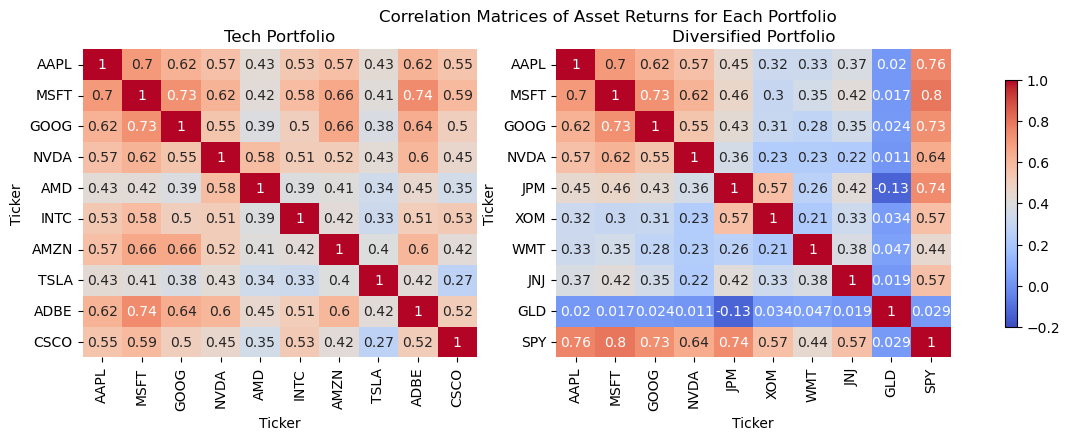

In [8]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Correlation Matrices of Asset Returns for Each Portfolio")

vmin = -0.2
vmax = 1

sns.heatmap(tech.corr_matrix(), annot=True, cmap='coolwarm', vmin=vmin, vmax=vmax, cbar=False, ax=axes[0])
axes[0].set_title("Tech Portfolio")

heatmap = sns.heatmap(div.corr_matrix(), annot=True, cmap='coolwarm', vmin=vmin, vmax=vmax, cbar=False, ax=axes[1])
axes[1].set_title("Diversified Portfolio")

for ax in axes: ax.tick_params(axis='x', labelrotation=90)

cbar = fig.colorbar(
    heatmap.collections[0],
    ax=axes,
    shrink=0.8
)
plt.savefig("plots/portfolio_corr_matrices_comparison")
plt.show()

The above comparison shows that correlations between assets in the concentrated tech portfolio are higher. This causes higher covariances, and thus higher portfolio variance and volatility. 

## Diversification Experiment

This experiment shows how as the number of assets in the portfolio and diversification increase, portfolio volatility tends to decrease, but then eventually stabilise. This is because while diversification reduces the effect of non-systematic risk, the effect of systematic risk remains.

The average volatility of a portfolio of each number of assets from the 10 tickers, from 1-10 is calculated, by finding all the different selections of assets of each size, and averaging their volatilities. If using more than 10 total tickers/assets, the total number of possible portfolios of size n may become quite large, in which cases a random selection of the possible portfolios of the required size is suitable.

This experiment is first done for the list of 10 tickers in the diversified portfolio.

In [9]:
from itertools import combinations

def diversification_experiment(tickers):
    portfolio_sizes = range(1, len(tickers)+1)
    
    avg_vols_div = []
    
    for n in portfolio_sizes:
        vols = []
        all_portfolio_selections = [list(combo) for combo in combinations(tickers, n)]
        for selection in all_portfolio_selections:
            portfolio = Portfolio(selection)
            vol = portfolio.volatility()
            vols.append(vol)
        avg_vols_div.append(np.mean(vols))
    return (portfolio_sizes, avg_vols_div)

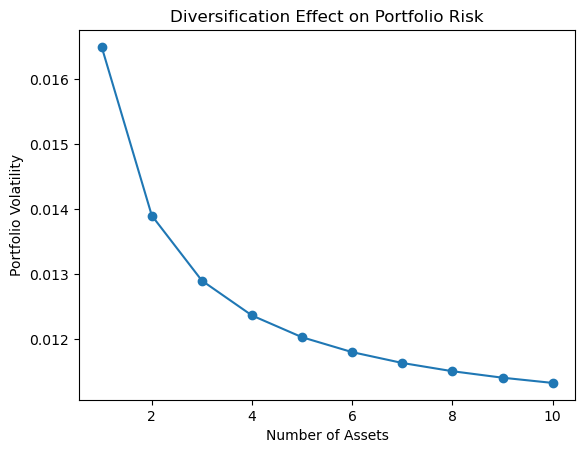

In [10]:
plt.plot(diversification_experiment(div_ticks)[0], diversification_experiment(div_ticks)[1], marker='o')

plt.xlabel("Number of Assets")
plt.ylabel("Portfolio Volatility")
plt.title("Diversification Effect on Portfolio Risk")

plt.savefig("plots/diversification_experiment_div")
plt.show()

Initially as the number of assets increases, the portfolio volatility decreases by a greater amount, but the decreasing effect decreases for larger numbers of assets, and an asymptotic behaviour is observed. This is because while diversifying reduces non-systematic risk, such as due to company-specific news etc., it does not reduce the underlying market risk. The asymptote approached approximates the shared-market component of volatility remaining after diversification. 

This shows that while diversification is useful to reduce non-systematic risk, it usually cannot reduce market/systematic risk without proportionally reducing returns.

The same experiment is performed below, but with a list of assets that are all tech-related.

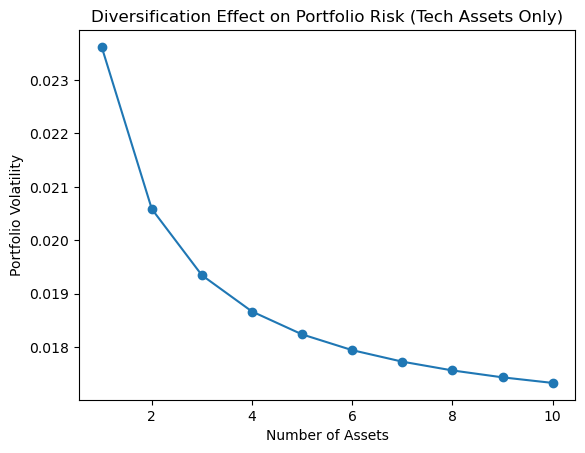

In [11]:
plt.plot(diversification_experiment(tech_ticks)[0], diversification_experiment(tech_ticks)[1], marker='o')

plt.xlabel("Number of Assets")
plt.ylabel("Portfolio Volatility")
plt.title("Diversification Effect on Portfolio Risk (Tech Assets Only)")

plt.show()

Both experiments show the same shape of the graph and trend of asymptotically decreasing portfolio volatility as number of assets in the portfolio increases. However, volatility flattens at a higher value for portfolios of only tech assets compared to a diversified portfolio. This shows how stronger correlations between assets in a portfolio reduce the effectiveness of diversification. 

## Feasible Portfolio Simulation

This is a simulation of all of the portfolios from each set of tickers (div_ticks and tech_ticks) with different weights. First, a function is created to generate a results array of the simulation with the daily portfolio return and volatility for each simulated portfolio, and then another function that either creates a standalone plot, or create a plot that can be added to an axes object.

In [12]:
def feasible_portfolios(tickers, num_portfolios = 5000):
    ticker_returns = returns[tickers]

    mu = ticker_returns.mean()
    cov = ticker_returns.cov()
    
    results = []
    
    for _ in range(num_portfolios):
    
        w = np.random.random(len(tickers))
        w /= np.sum(w)

        port_return = np.dot(w, mu)
        port_var = np.dot(w, np.dot(cov, w))
        port_vol = np.sqrt(port_var)
        
        results.append([port_return, port_vol])
    
    return np.array(results)

def plot_feasible_portfolios(results, ax=None):
    if not ax:
        plt.scatter(results[:,1], results[:,0], alpha=0.5)
        plt.title("Plot of Feasible Portfolios")
        plt.xlabel("Daily Volatility")
        plt.ylabel("Daily Expected Return")
    else:
        ax.scatter(results[:,1], results[:,0], alpha=0.5)
    
        ax.set_xlabel("Daily Volatility")
        ax.set_ylabel("Dailty Expected Return")

Now, the feasible portfolios from the tickers are plotted for both the diversified and tech sets of tickers, side by side. 

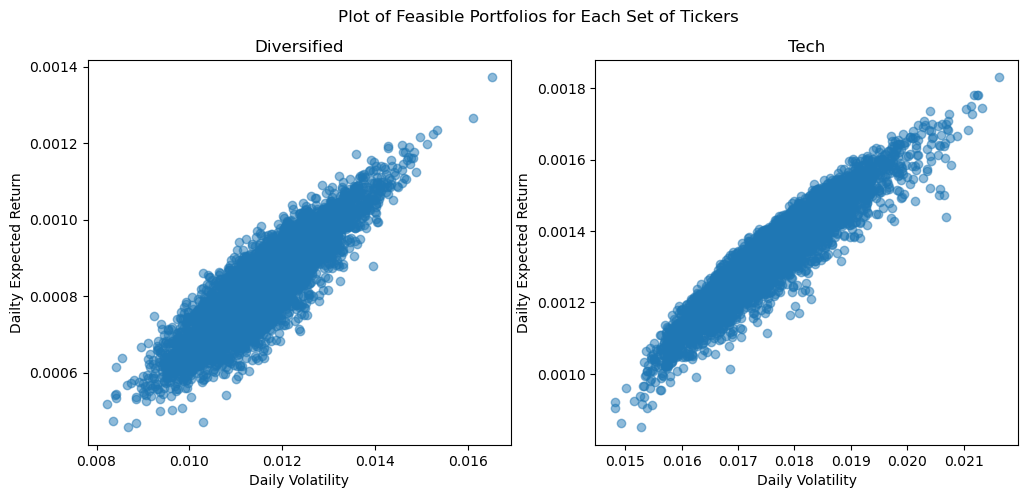

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

fig.suptitle("Plot of Feasible Portfolios for Each Set of Tickers")

plot_feasible_portfolios(feasible_portfolios(div_ticks), axes[0])
axes[0].set_title("Diversified")

plot_feasible_portfolios(feasible_portfolios(tech_ticks), axes[1])
axes[1].set_title("Tech")

plt.savefig("plots/feasible_portfolio_plots")
plt.show()

- One difference is that for the tech tickers, there is less spread of the points from the main trend, compared to the diversified tickers. This is because all the assets are tech assets which already behave quite similarly (more highly correlated), so changing portfolio weights has less impact on overall risk and return.
- Also, the tech plot lies over higher volatility and higher expected return ranges than the diversified plot, similar to how the equal weighted portfolio of tech tickers had higher volatility and expected return than that of the diversified tickers.
- Finally, while these plots were expected to appear like the classic expected frontier simulation shape, the plots created appear to have more of a linear trend. This is likely due to all the tickers having relatively high correlations, with most correlations being positive. However, the efficient frontier can still be visualised as the upper left outline of each of these portfolios, where return is maximised for given risk. 

## Beta and CAPM


### Beta Estimation
Beta(ß) of a portfolio is a measure of systematic risk and volatility of an asset compared to the broader market, usually a benchmark such as SPY (which is used here). Beta above 1 means higher volatility than the market, whereas beta below 1 means less volatility than the market. 
It is calculated by:
$$\beta_i = \frac{Cov(R_i, R_m)}{Var(R_m)}
$$
where R_m is the market return, for which the return of SPY will be used as a proxy. 

This formula indicates how beta can also be interpreted as the slope coefficient in a linear regression of asset returns against market returns, which aligns with the idea that beta is a measure of how much asset returns change per given amount of change in market returns.

In [14]:
betas = returns.cov()["SPY"]/returns["SPY"].var()

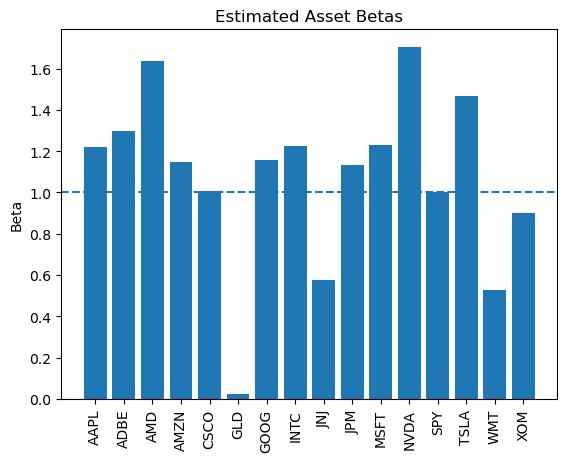

In [15]:
plt.bar(betas.index, betas)
plt.axhline(1, linestyle="--")
plt.title("Estimated Asset Betas")
plt.ylabel("Beta")
plt.xticks(rotation=90)
plt.savefig("plots/estimated_asset_betas")
plt.show()

- NVDA, AMD and TSLA had the highest betas, all above 1.4. This is expected as historically they have had larger price swings, and larger reactions to market sentiment and growth expectations, showing greater sensitivity to market changes.
- All tech assets had betas above 1, most of them appreciably so, which also makes sense as large growth-oriented tech stocks often amplify market moves.
- SPY had a beta of 1, which is the theoretical value, since SPY is used as a proxy for the market itself here.
- The non-tech assets other than JPM had betas less than 1, which is expected as they are defensive stocks.
- GLD has a beta of 0.02, which is almost 0, showing that it has almost no systematic market exposure. This also aligns with its low correlations with other assets, seen in the correlation matrix. 

### Capital Asset Pricing Model (CAPM)

CAPM is a model that describes the relationship between risk and expected return of investing in a security. It says that expected return is equal to risk-free interest rate plus a risk premium. It is given by this formula:
$$E(R_i) = R_f + \beta_i\times[E(R_m)-R_f]
$$
where R_f is the risk-free interest rate, often determined by current government bond yield.

In [16]:
annual_rf = 0.024 # ~2.40% average 10-year US treasury yield over the 2015-2023 historical period

daily_rf = (1 + annual_rf) ** (1/252) - 1 # using compounding formula

capm_returns = daily_rf + betas * (returns["SPY"].mean() - daily_rf)

historical_returns = returns.mean()

comparison = pd.DataFrame({
    "Beta": betas,
    "CAPM Return": capm_returns,
    "Historical Return": historical_returns
})

comparison.sort_values("Beta")

,Beta,CAPM Return,Historical Return
Ticker,,,
GLD,0.022305,0.000103,0.000267
WMT,0.527164,0.000312,0.000443
JNJ,0.576147,0.000332,0.000354
XOM,0.902887,0.000467,0.000373
SPY,1.000000,0.000507,0.000507
CSCO,1.007908,0.000511,0.000520
JPM,1.134769,0.000563,0.000704
AMZN,1.146331,0.000568,0.001230
GOOG,1.155893,0.000572,0.000906


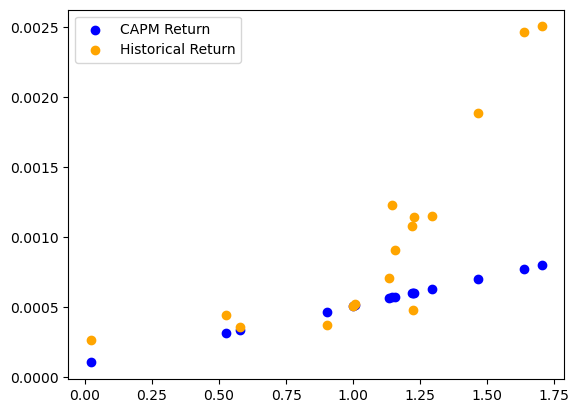

In [17]:
plt.scatter(betas, capm_returns, label="CAPM Return", color="blue")
plt.scatter(betas, historical_returns, label="Historical Return", color="orange")
plt.legend()
plt.show()

The CAPM return estimates are quite far off the historical estimates for many of the assets, especially with historical returns being higher than the CAPM estimates. This suggests that many of these assets outperformed what CAPM would predict based solely on market risk. This is where the concept of alpha can appear.\
\
Earlier, we had the formula for CAPM return estimate:
$$E(R_i) = R_f + \beta_i[E(R_m)-R_f]
$$
This can be rearranged to get:
$$E(R_i)-R_f=\beta_i[E(R_m)-R_f]
$$
To this we can also add alpha, as the excess return unexplained by just market exposure, and get the standard regression form:
$$R_i-R_f=\alpha_i+\beta_i[R_m-R_f]
$$
we can now calculate alpha:
$$\alpha_i=R_i-R_f-\beta_i[R_m-R_f]=R_i-(R_f+\beta_i[R_m-R_f])=R_i-E(R_i)
$$
So it is just historical return minus the CAPM return estimate.

In [18]:
comparison["Alpha"] = historical_returns-capm_returns
comparison.sort_values("Alpha")

,Beta,CAPM Return,Historical Return,Alpha
Ticker,,,,
INTC,1.223808,0.000600,0.000477,-1.225314e-04
XOM,0.902887,0.000467,0.000373,-9.465307e-05
SPY,1.000000,0.000507,0.000507,2.168404e-19
CSCO,1.007908,0.000511,0.000520,9.204148e-06
JNJ,0.576147,0.000332,0.000354,2.200490e-05
WMT,0.527164,0.000312,0.000443,1.309290e-04
JPM,1.134769,0.000563,0.000704,1.410210e-04
GLD,0.022305,0.000103,0.000267,1.637967e-04
GOOG,1.155893,0.000572,0.000906,3.342042e-04


CAPM explains returns using systematic market risk. However, several growth-oriented technology stocks achieved returns substantially above CAPM predictions, leading to systematically positive alpha estimates for high-growth equities. This suggests that factors beyond market exposure contributed significantly to realised performance, and market beta alone was insufficient. Furthermore, the selection of large-cap surviving equities  introduced upward bias.

### Rolling Beta and CAPM

The rolling beta and CAPM will be computed for the diversified portfolio (div_ticks). For an equally weighted portfolio, the portfolio returns for each day is the average of the asset returns, and this is repeated for all days to create the portfolio_returns series. A window of 252 days (1 trading year) is used. 

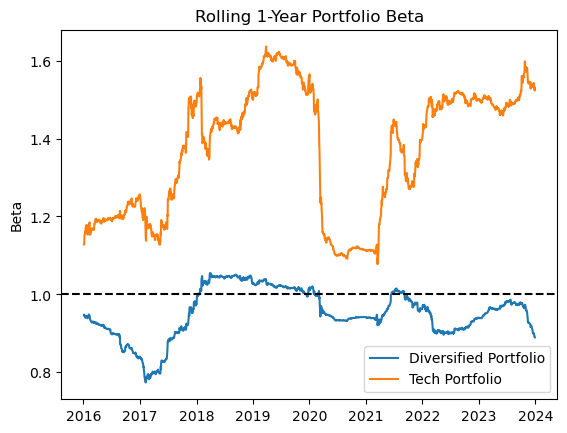

In [19]:
def rolling_beta(portfolio_returns, market_returns=returns["SPY"], window=252):
    rolling_beta = (
    portfolio_returns.rolling(window).cov(market_returns) # rolling covariance value between the portfolio returns and market returns 
    /
    market_returns.rolling(window).var()
    )
    return rolling_beta

div_portfolio_returns = returns[div_ticks].mean(axis=1) # for an equally weighted portfolio, portfolio_returns are weighted sum of asset returns
tech_portfolio_returns = returns[tech_ticks].mean(axis=1)

div_rolling_beta = rolling_beta(div_portfolio_returns)
tech_rolling_beta = rolling_beta(tech_portfolio_returns)

plt.plot(div_rolling_beta, label="Diversified Portfolio")
plt.plot(tech_rolling_beta, label="Tech Portfolio")

plt.axhline(1, linestyle="--", color="black")

plt.title("Rolling 1-Year Portfolio Beta")
plt.ylabel("Beta")
plt.legend()

plt.show()

The technology portfolio exhibited both a higher average beta and greater beta variability than the diversified portfolio, indicating greater and less stable exposure to systematic market risk. Diversification reduced not only overall portfolio volatility but also the sensitivity of market exposure over time.

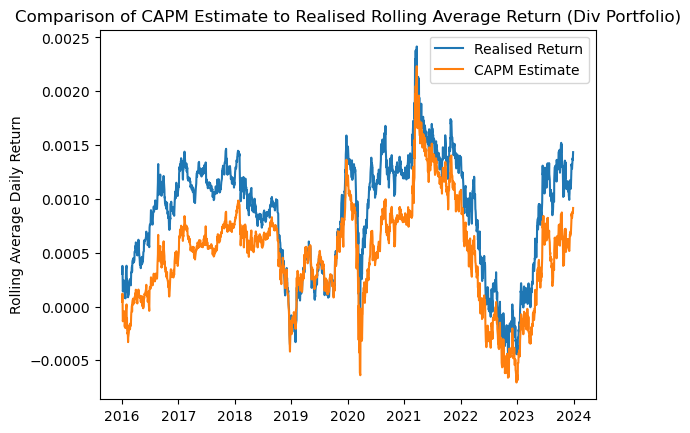

In [20]:
window = 252

rolling_rm = returns["SPY"].rolling(window).mean() # rolling market returns

rolling_capm = (daily_rf + div_rolling_beta * (rolling_rm - daily_rf))

realised_rolling_returns = div_portfolio_returns.rolling(window).mean()

plt.plot(realised_rolling_returns, label="Realised Return")
plt.plot(rolling_capm, label="CAPM Estimate")
plt.title("Comparison of CAPM Estimate to Realised Rolling Average Return (Div Portfolio)")
plt.ylabel("Rolling Average Daily Return")

plt.legend()
plt.show()

Using a rolling one-year window, CAPM-implied expected returns were compared with realised average portfolio returns over the same period. The two series broadly tracked each other, although realised returns were frequently higher, suggesting periods of positive alpha and performance beyond what would be predicted by market exposure alone.

## Monte Carlo Simulation of Portfolio Value

1 year (252 days) of returns of each portfolio is simulated 10000 times, with the final wealth at the end of each simulated year measured and stored. Portfolio returns are modelled using a multivariate normal distribution, with parameters mu (µ), a column vector of average returns for each asset, and cov (Σ), the covariance matrix of the returns of the assets, over the observed period. In the simulation, we first start with an array of returns values generated randomly from the standard normal distribution. These values are then transformed by matrix multiplication with the Cholesky Decomposition of the covariance matrix which introduces the correlation structure of the portfolio, and then addition of the column vector of average returns to each day's results to introduce the "drift" in values. This correlated returns matrix is then multiplied by the weights vector to obtain the final portfolio returns series. The final wealth of the portfolio (as a multiple of initial wealth) is then determined by accumulation of the daily portfolio returns over the year with a cumulative product. For each simulation, this final wealth is stored as the output of the function.

In [21]:
def monte_carlo_portfolio(tickers, n_sims=10000, n_days=252):

    data = returns[tickers]
    mu = data.mean().values
    cov = data.cov().values

    L = np.linalg.cholesky(cov) #Cholesky Decomposition

    w = np.ones(len(tickers)) / len(tickers)

    final_values = []

    for _ in range(n_sims):
        
        z = np.random.normal(size=(n_days, len(tickers)))
        correlated = z @ L + mu #transformation of standard normal

        portfolio_returns = correlated @ w
        wealth = np.cumprod(1 + portfolio_returns)

        final_values.append(wealth[-1])

    return np.array(final_values)

The Monte Carlo simulation models portfolio dynamics using multivariate normally distributed simple returns calibrated from historical data, with compounding performed via geometric accumulation of returns.

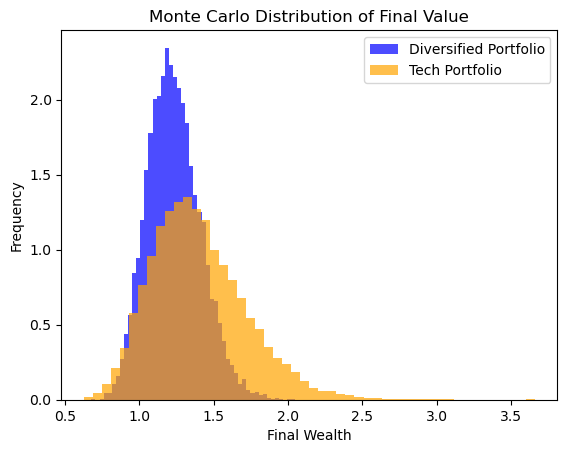

In [22]:
monte_carlo_div_results = monte_carlo_portfolio(div_ticks)
monte_carlo_tech_results = monte_carlo_portfolio(tech_ticks)


plt.hist(monte_carlo_div_results, bins = 50, alpha = 0.7, label="Diversified Portfolio", color='blue', density = True)
plt.hist(monte_carlo_tech_results, bins = 50, alpha = 0.7, label="Tech Portfolio", color='orange', density = True)
plt.title("Monte Carlo Distribution of Final Value")
plt.xlabel("Final Wealth")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plots/monte_carlo_distributions")
plt.show()

The tech portfolio's distribution has a higher mean but also greater dispersion. This suggests higher expected returns together with greater uncertainty in outcomes.We now create a function to analyse the distribution of final values and calculate key measures. 

In [23]:
def mc_results_analysis(results):
    return {
        'Mean': results.mean(),
        'Variance': results.var(),
        'Standard Deviation': results.std(),
        'Minimum': results.min(),
        'Maximum': results.max(),
        '95% VaR': np.percentile(results, 5), # 5th percentile of final portfolio wealth
        '95% CVaR': results[results <= np.percentile(results, 5)].mean(), # average final wealth among the worst 5% of simulations
        'Probability of Loss': np.mean(results < 1)
    }

In [24]:
div_mc_analysis = mc_results_analysis(monte_carlo_div_results)
tech_mc_analysis = mc_results_analysis(monte_carlo_tech_results)

In [25]:
comparison = pd.DataFrame([
    div_mc_analysis,
    tech_mc_analysis
], index=["Diversified", "Tech"])

comparison

,Mean,Variance,Standard Deviation,Minimum,Maximum,95% VaR,95% CVaR,Probability of Loss
Diversified,1.232059,0.031999,0.178884,0.677041,2.049587,0.958743,0.903562,0.0880
Tech,1.397511,0.101282,0.318248,0.627017,3.660984,0.941173,0.861431,0.0855


Observations:
- The tech portfolio's distribution has higher mean and also a higher maximum value. This means that on average, the tech portfolio will yield higher returns and gains, and can yield higher returns in the best-case scenario. This comparison reflects previous observations of the average daily return of each portfolio.
- On the other hand, the tech portfolio's distribution also has higher variance and standard deviation, indicating greater volatility of annual return. There is also a lower minimum observed, indicating a lower worst-case value. The 95% Value at Risk (VaR) and 95% Conditional Value at Risk (CVaR) for the tech portfolio are also lower, indicating greater downside risk. These comparisons also reflect previous observations that the average daily return of the tech portfolio had greater volatility. The tech portfolio can be considered a more risky investment.
- Interestingly, the probability of loss for the diversified portfolio is greater than that for the tech portfolio, though they are similar. This indicates that the effect of higher variance and standard deviation is offset by a greater mean of the distribution for the tech portfolio, at least when it comes the metric of probability of loss. Even though the probability of loss is similar for both portfolios, the losses observed in the case of a loss are generally smaller for the diversified portfolio, which can be seen in their portfolios' histograms.
- Overall, while the tech portfolio seems to yield greater annual returns on average, these annual returns have greater volatility, leading to greater downside risk. There is a trade-off between risk and return observed by comparing the two portfolios.
- A note is that in this project, there is a bit of survivorship/look-ahead bias in selection of the assets that make up each portfolio, particularly in the tech portfolio, as the assets selected tend to be those that have performed well over the historical period 2015-2024 ("winners" over the period) which is why they are well-known now and happened to be chosen. These greater returns over the period led to calculated averages being higher, and thus greater predicted average returns over a hypothetical future period, leading to slight anomalies like the observation above of similar probability of losses for both portfolios. For a better comparison of a diversified portfolio and a tech portfolio to understand the consequences of diversification, it would perhaps be better to select assets based only on what a retail investor in 2015 would have known.